# Merton consumption-portfolio (log utility)

A textbook benchmark: the consumption-savings problem with a single
risky asset and log utility, which admits a clean closed-form solution.
We use it as bellgrid's correctness contract.

## Problem

A household with current wealth $w_t$ chooses consumption $c_t \in (0, w_t]$
at each period. Remaining wealth $w_t - c_t$ earns a stochastic gross
return $R_{t+1} = \exp(\mu + \sigma Z_{t+1})$ where $Z \sim \mathcal{N}(0, 1)$.
The household maximises

$$ \mathbb{E}\!\left[ \sum_{t=0}^{\infty} \beta^t \log c_t \right] $$

subject to $w_{t+1} = (w_t - c_t)\, R_{t+1}$ and $c_t \in (0, w_t]$.

## Closed form

Conjecture $V(w) = A + B \log w$. Solving the Bellman equation gives

$$ B = \frac{1}{1-\beta}, \qquad
   A = \frac{\log(1-\beta)}{1-\beta} + \frac{\beta}{(1-\beta)^2}\bigl(\log\beta + \mu\bigr). $$

The optimal policy is a **constant consumption rate**:

$$ c^*_t = (1-\beta)\, w_t. $$

We validate against the closed form two ways:

1. **Finite-horizon backward induction** with $V_T = A + B \log w$ as
   the terminal reward. Since $V^*$ is a fixed point of the Bellman
   operator, the truncated DP sits in steady state at every $t$.
2. **Infinite-horizon policy iteration** with no terminal reward.
   Iterate the Bellman operator from $V_0 = 0$ until convergence; the
   result is $V^*$ up to discretization error, with no truncation hack.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from bellgrid import (
    ContinuousAction,
    ContinuousState,
    Problem,
    simulate,
    solve,
)
from bellgrid.grids import RegularGrid, WarpedGrid
from bellgrid.shocks import Normal
from bellgrid.solvers import BackwardInduction, PolicyIteration

## Parameters

In [2]:
beta = 0.96   # discount factor
mu = 0.04     # mean log return
sigma = 0.15  # log-return volatility
T = 20        # truncation horizon

# closed-form coefficients
B = 1.0 / (1.0 - beta)
A = (
    math.log(1.0 - beta) / (1.0 - beta)
    + (beta / (1.0 - beta) ** 2) * (math.log(beta) + mu)
)
expected_rate = 1.0 - beta

print(f"closed form: c/w = {expected_rate:.4f}, V(w) = {A:.4f} + {B:.4f}*log(w)")

closed form: c/w = 0.0400, V(w) = -80.9651 + 25.0000*log(w)


## Finite-horizon problem (backward induction)

Wealth lives on an asinh-warped grid so points concentrate near zero
(where the value function has the most curvature). The terminal reward
is the closed-form $V$, so the truncated DP reproduces the stationary
solution at every interior $t$.

In [3]:
def transition(state, action, shock, _t):
    return {
        "wealth": (state["wealth"] - action["consume"])
        * torch.exp(mu + sigma * shock["z"])
    }


def reward(_state, action, _shock, _t):
    return torch.log(action["consume"])


def terminal_reward(state):
    return A + B * torch.log(state["wealth"])


# Set the wealth range well above the highest spot we'll query: clamp-at-edge
# interpolation is the dominant error source for problems where the value
# function is unbounded (here V grows as log w). Roughly, accurate results
# at wealth w require the grid to extend to ~4w or more.
problem = Problem(
    states=[ContinuousState("wealth", warp="asinh", range=(1e-3, 200.0))],
    actions=[ContinuousAction("consume", bounds=(1e-6, "wealth"))],
    transition=transition,
    reward=reward,
    shocks=[Normal("z", sigma=1.0)],
    horizon=range(0, T),
    discount=beta,
    terminal_reward=terminal_reward,
)

policy, value = solve(
    problem,
    state_grid={"wealth": WarpedGrid(n=128)},
    action_grid={"consume": RegularGrid(n=500)},
    solver=BackwardInduction(n_quad=7),
)

## Consumption rate: bellgrid vs closed form

The optimal policy is constant in wealth: $c^*/w = 1 - \beta$. The
solver should recover that flat line across the support.

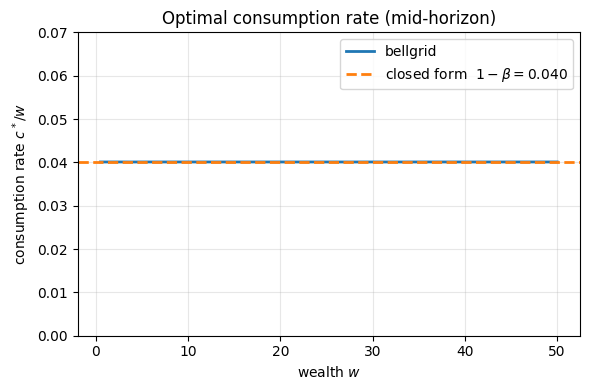

In [4]:
w_query = torch.linspace(0.5, 50.0, 200, dtype=torch.float64)
c_bellgrid = policy({"wealth": w_query}, t=T // 2)["consume"]
rate_bellgrid = (c_bellgrid / w_query).numpy()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(w_query.numpy(), rate_bellgrid, label="bellgrid", lw=2)
ax.axhline(expected_rate, color="C1", ls="--", lw=2, label=f"closed form  $1-\\beta = {expected_rate:.3f}$")
ax.set_xlabel("wealth $w$")
ax.set_ylabel("consumption rate $c^* / w$")
ax.set_title("Optimal consumption rate (mid-horizon)")
ax.set_ylim(0.0, 0.07)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Value function: bellgrid vs closed form

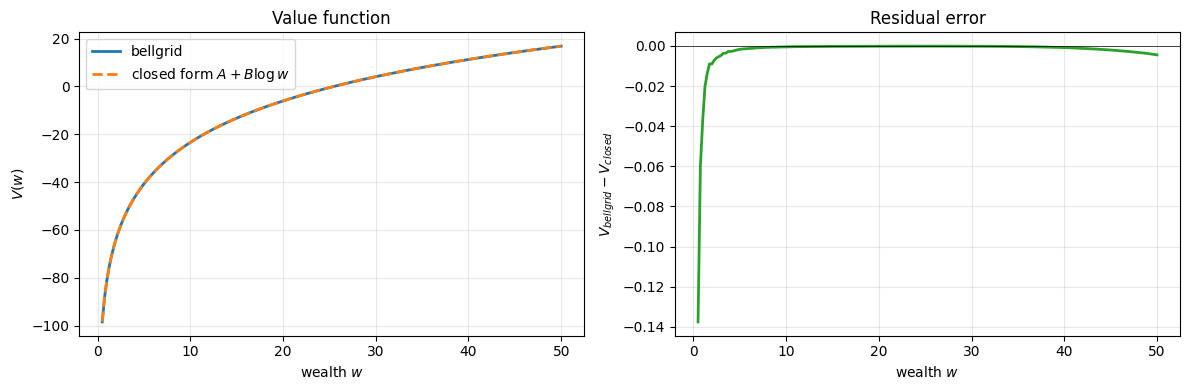

In [5]:
v_bellgrid = value({"wealth": w_query}, t=T // 2).numpy()
v_closed = (A + B * torch.log(w_query)).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(w_query.numpy(), v_bellgrid, label="bellgrid", lw=2)
ax1.plot(w_query.numpy(), v_closed, ls="--", lw=2, label="closed form $A + B \\log w$")
ax1.set_xlabel("wealth $w$")
ax1.set_ylabel("$V(w)$")
ax1.set_title("Value function")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(w_query.numpy(), v_bellgrid - v_closed, lw=2, color="C2")
ax2.axhline(0.0, color="black", lw=0.5)
ax2.set_xlabel("wealth $w$")
ax2.set_ylabel("$V_{bellgrid} - V_{closed}$")
ax2.set_title("Residual error")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Infinite-horizon problem (policy iteration)

Same `transition` and `reward` as the finite-horizon problem, but with
`horizon=None` and no `terminal_reward`. `PolicyIteration` iterates the
Bellman operator from $V_0 = 0$ until $\|V_\text{new} - V\|_\infty < \mathrm{tol}$.
The Bellman operator is a contraction with factor $\beta$, so
convergence is geometric: at $\beta = 0.96$ and $\mathrm{tol} = 10^{-7}$
expect a few hundred iterations.

**No terminal-reward hack here** — the answer comes purely from
iterating the operator to its fixed point.

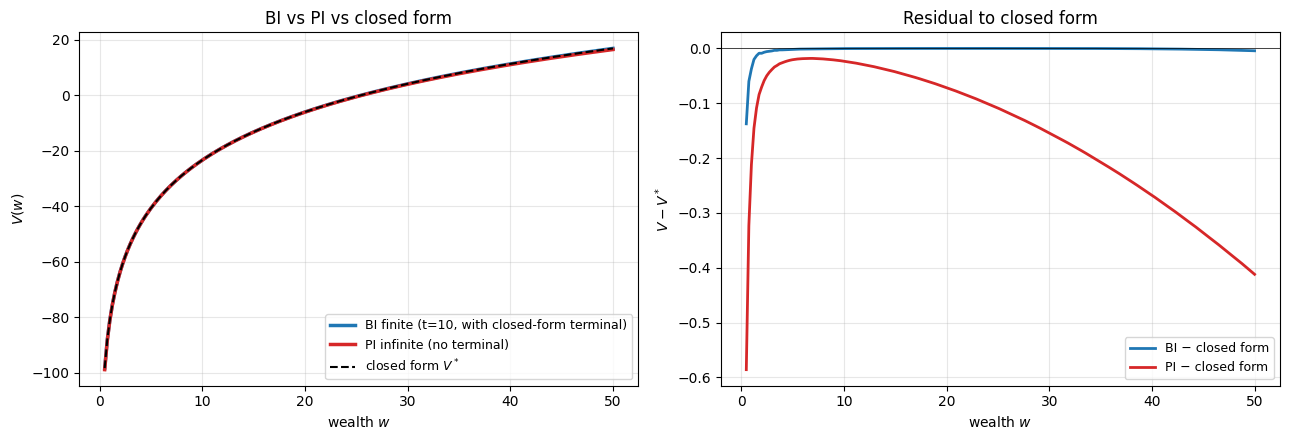

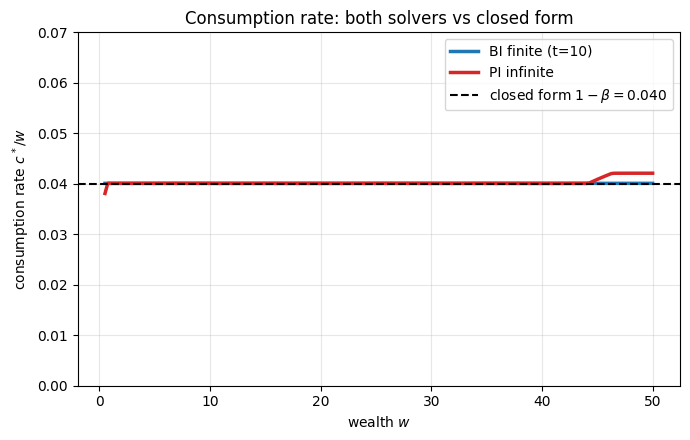

In [6]:
problem_inf = Problem(
    states=problem.states,
    actions=problem.actions,
    transition=transition,
    reward=reward,
    shocks=problem.shocks,
    horizon=None,
    discount=beta,
    # no terminal_reward: V_0 = 0
)

policy_inf, value_inf = solve(
    problem_inf,
    state_grid={"wealth": WarpedGrid(n=128)},
    action_grid={"consume": RegularGrid(n=500)},
    solver=PolicyIteration(n_quad=7, tol=1e-7),
)

v_inf = value_inf({"wealth": w_query}, t=None).numpy()
rate_inf = (policy_inf({"wealth": w_query}, t=None)["consume"] / w_query).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(w_query.numpy(), v_bellgrid, lw=2.5, color="C0",
         label=f"BI finite (t={T // 2}, with closed-form terminal)")
ax1.plot(w_query.numpy(), v_inf, lw=2.5, color="C3",
         label="PI infinite (no terminal)")
ax1.plot(w_query.numpy(), v_closed, ls="--", color="black", lw=1.5,
         label="closed form $V^*$")
ax1.set_xlabel("wealth $w$")
ax1.set_ylabel("$V(w)$")
ax1.set_title("BI vs PI vs closed form")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(w_query.numpy(), v_bellgrid - v_closed, lw=2, color="C0",
         label="BI − closed form")
ax2.plot(w_query.numpy(), v_inf - v_closed, lw=2, color="C3",
         label="PI − closed form")
ax2.axhline(0.0, color="black", lw=0.5)
ax2.set_xlabel("wealth $w$")
ax2.set_ylabel("$V - V^*$")
ax2.set_title("Residual to closed form")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Consumption rates side-by-side
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(w_query.numpy(), rate_bellgrid, lw=2.5, color="C0",
        label=f"BI finite (t={T // 2})")
ax.plot(w_query.numpy(), rate_inf, lw=2.5, color="C3",
        label="PI infinite")
ax.axhline(expected_rate, color="black", ls="--", lw=1.5,
           label=f"closed form $1-\\beta = {expected_rate:.3f}$")
ax.set_xlabel("wealth $w$")
ax.set_ylabel("consumption rate $c^* / w$")
ax.set_title("Consumption rate: both solvers vs closed form")
ax.set_ylim(0.0, 0.07)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Forward simulation

Draw 200 paths from $w_0 = 10$ under the bellgrid policy. The
closed-form theory says wealth should drift at rate
$\beta \cdot \mathbb{E}[R]$ per period and consumption is a constant
fraction of wealth at every $t$.

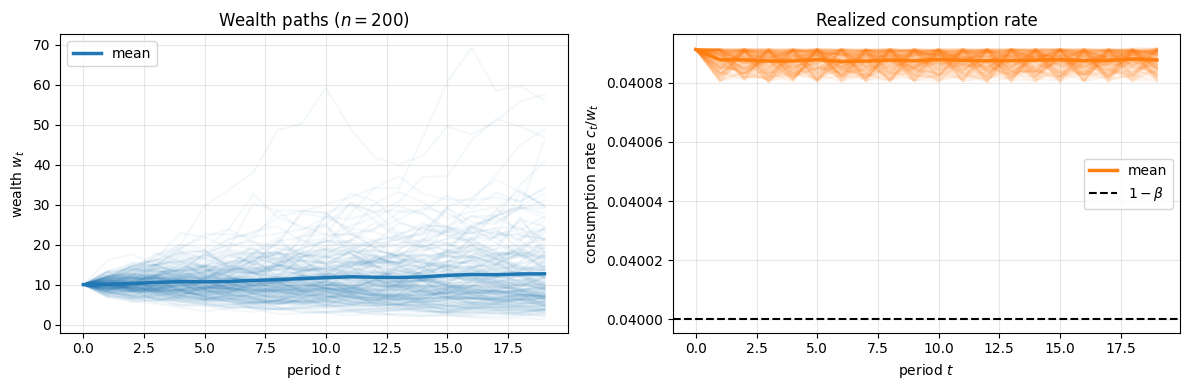

In [7]:
n_paths = 200
paths = simulate(
    policy=policy,
    problem=problem,
    n=n_paths,
    initial_state={"wealth": 10.0},
    seed=0,
)
paths_cpu = {k: v.cpu() for k, v in paths.items()}

t_axis = np.arange(T)
wealth = paths_cpu["wealth"].numpy()
consume = paths_cpu["consume"].numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(t_axis, wealth.T, color="C0", alpha=0.05)
ax1.plot(t_axis, wealth.mean(axis=0), color="C0", lw=2.5, label="mean")
ax1.set_xlabel("period $t$")
ax1.set_ylabel("wealth $w_t$")
ax1.set_title(f"Wealth paths ($n = {n_paths}$)")
ax1.legend()
ax1.grid(alpha=0.3)

# Consumption rate at each step should hover at 1 - beta
rate_paths = consume / wealth
ax2.plot(t_axis, rate_paths.T, color="C1", alpha=0.05)
ax2.plot(t_axis, rate_paths.mean(axis=0), color="C1", lw=2.5, label="mean")
ax2.axhline(expected_rate, color="black", ls="--", lw=1.5, label=f"$1 - \\beta$")
ax2.set_xlabel("period $t$")
ax2.set_ylabel("consumption rate $c_t / w_t$")
ax2.set_title("Realized consumption rate")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Convergence: error vs state-grid resolution

Multilinear interpolation under an asinh warp is *exact* on linear-in-warp
functions; the residual comes from quadrature plus action-grid discretisation.
Doubling the wealth-grid resolution should approximately quarter the V error.

  n_wealth        h      max |Δ V|    max |Δ c/w|
--------------------------------------------------
        32   1.6129     1.7853e-01     2.6791e-04
        64   0.7936     4.0982e-02     1.2542e-04
       128   0.3937     8.9067e-03     9.1438e-05
       256   0.1961     2.4957e-03     8.3319e-05


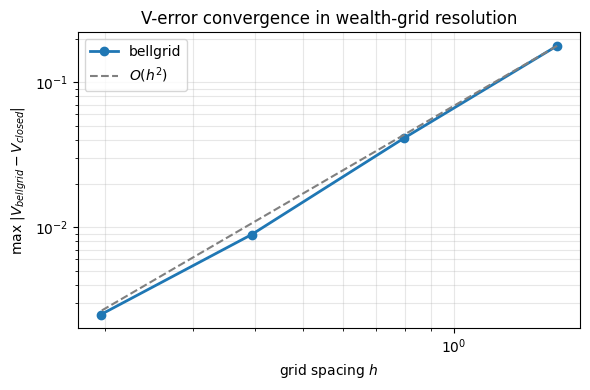

In [8]:
test_w = torch.tensor([2.0, 5.0, 10.0, 20.0], dtype=torch.float64)
v_cf = A + B * torch.log(test_w)
rows = []
for n_w in (32, 64, 128, 256):
    p, v = solve(
        problem,
        state_grid={"wealth": WarpedGrid(n=n_w)},
        action_grid={"consume": RegularGrid(n=500)},
        solver=BackwardInduction(n_quad=7),
    )
    v_err = (v({"wealth": test_w}, t=T // 2) - v_cf).abs().max().item()
    r_err = ((p({"wealth": test_w}, t=T // 2)["consume"] / test_w) - expected_rate).abs().max().item()
    rows.append((n_w, 49.999 / (n_w - 1), v_err, r_err))

print(f"{'n_wealth':>10} {'h':>8} {'max |Δ V|':>14} {'max |Δ c/w|':>14}")
print("-" * 50)
for n_w, h, v_err, r_err in rows:
    print(f"{n_w:>10d} {h:>8.4f} {v_err:>14.4e} {r_err:>14.4e}")

# Plot it too
hs = np.array([r[1] for r in rows])
v_errs = np.array([r[2] for r in rows])
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(hs, v_errs, "o-", lw=2, label="bellgrid")
ax.loglog(hs, v_errs[0] * (hs / hs[0]) ** 2, ls="--", color="gray", label="$O(h^2)$")
ax.set_xlabel("grid spacing $h$")
ax.set_ylabel("max $|V_{bellgrid} - V_{closed}|$")
ax.set_title("V-error convergence in wealth-grid resolution")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()